**Prediksi Cuaca Menggunakan Algoritma KNN Berbasis Data Suhu, Kelembaban, Tekanan Udara, dan Kecepatan Angin**

Divala Zahra Oktavia (230511009)

Faid Rama Daniy (2305110013)

Elya Syafa'atun Ni'mah (2305110030)

Teknik Komputer 2023

In [13]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


# ===== Load Dataset =====
df = pd.read_csv("weather_data_balanced.csv")

# Ambil hanya 3 kelas utama
df = df[df["Weather_Condition"].isin(["Sunny", "Rainy", "Stormy", "Cloudy"])]

X = df[["Temperature", "Humidity", "Wind_Speed", "Air_Pressure"]].values
y = df["Weather_Condition"].values

# Encode label manual
classes = {label: idx for idx, label in enumerate(np.unique(y))}
inv_classes = {v: k for k, v in classes.items()}
y = np.array([classes[label] for label in y])


# ===== Split train/test manual (80/20) =====
np.random.seed(1)
indices = np.arange(len(X))
np.random.shuffle(indices)

#split = int(0.8 * len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# ===== KNN From Scratch =====
class KNNClassifier:
    def __init__(self, k=9):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict_one(self, x):
        # Hitung jarak Euclidean ke semua data latih
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

        # Ambil k tetangga terdekat
        k_indices = distances.argsort()[:self.k]
        k_labels = self.y_train[k_indices]

        # Voting mayoritas
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]
    def show_nearest(self, x, n_neighbors=5):
        # Hitung jarak
        distances = np.sum(np.abs(self.X_train - x)**2, axis=1)

        # Urutkan dari jarak terkecil
        sorted_idx = np.argsort(distances)[:n_neighbors]

        print(f"\n{n_neighbors} data cuaca paling dekat dengan input:")
        print("=" * 60)
        for i, idx in enumerate(sorted_idx):
            print(f"{i+1}. Jarak = {distances[idx]:.3f} | Label = {inv_classes[self.y_train[idx]]}")
            print(f"   Fitur: {self.X_train[idx]}")
        print("=" * 60)

    def predict(self, X_test):
        return np.array([self.predict_one(x) for x in X_test])

# ===== Training & Evaluasi =====
knn = KNNClassifier(k=9)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Hitung akurasi manual
accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Akurasi (KNN From Scratch):", accuracy)

# Confusion Matrix manual
conf_matrix = pd.crosstab(
    [inv_classes[i] for i in y_test],
    [inv_classes[i] for i in y_pred],
    rownames=["Asli"],
    colnames=["Prediksi"],
    margins=True
)

# ===== Prediksi Input Baru =====
# Format fitur: [Temp_C, Rel Hum_%, Wind Speed_km/h, Press_kPa]
Sample = np.array([26.42, 28, 2, 1010.2])  # contoh input

pred_label = knn.predict_one(Sample)
print("\nPrediksi cuaca untuk input", Sample, "adalah:", inv_classes[pred_label])


Akurasi (KNN From Scratch): 0.96875

Prediksi cuaca untuk input [  26.42   28.      2.   1010.2 ] adalah: Sunny


Metode PCA

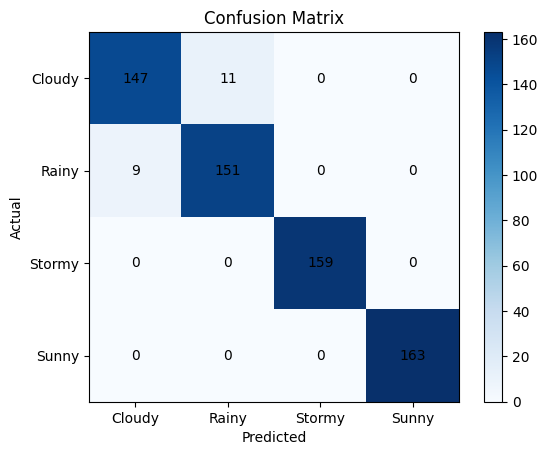

In [14]:
# ===== Visualisasi Confusion Matrix =====
cm = conf_matrix.iloc[:-1, :-1].values  
labels = conf_matrix.columns[:-1]       # nama kolom prediksi

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')

# Tampilkan nilai dalam setiap kotak
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

# Label sumbu
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(conf_matrix.index[:-1])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.title('Confusion Matrix')
plt.colorbar(im)
plt.show()


In [15]:
def pca(X, n_components=2):
    # 1. Mean centering
    mean_X = np.mean(X, axis=0)
    X_centered = X - mean_X

    # 2. Covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # 3. Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # 4. Urutkan dari eigenvalue terbesar ke kecil
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, sorted_idx]
    eigenvalues = eigenvalues[sorted_idx]

    # 5. Ambil n_components
    components = eigenvectors[:, :n_components]

    # 6. Proyeksikan data
    X_reduced = np.dot(X_centered, components)

    return X_reduced, components, eigenvalues, mean_X


Visualisasi Sample

[  6.31539453 -34.46421484 -16.84408594  21.1573125 ]


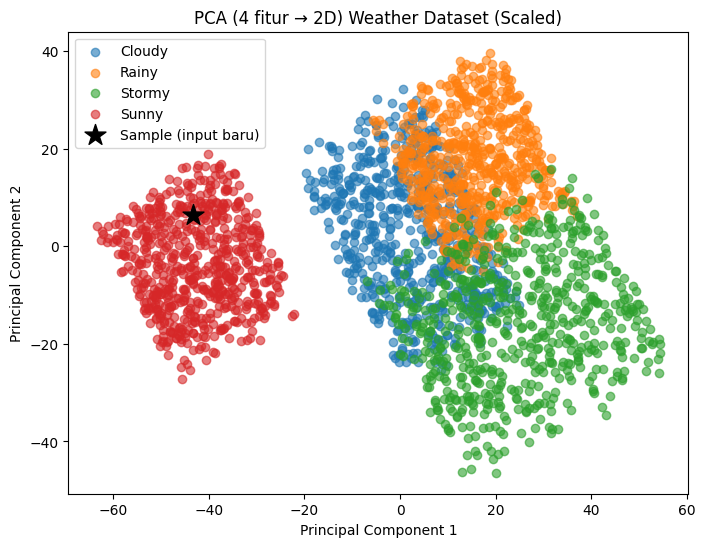

In [16]:
# ===== Standarisasi fitur sebelum PCA =====

# Jalankan PCA
X_pca, components, eigenvalues, mean_pca = pca(X_train, n_components=2)
sample_centered = Sample - mean_pca
sample_reduced = np.dot(sample_centered, components)
print(sample_centered)


# Plot
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    plt.scatter(X_pca[y_train == label, 0],
                X_pca[y_train == label, 1],
                label=inv_classes[label], alpha=0.6)

plt.scatter(sample_reduced[0], sample_reduced[1],
            color='black', marker='*', s=250, label='Sample (input baru)')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA (4 fitur → 2D) Weather Dataset (Scaled)")
plt.legend()
plt.show()


In [17]:
def visualisasi_input(p):
  input_centered = p - mean_pca
  input_reduced = np.dot(input_centered, components)
  # Plot
  plt.figure(figsize=(8,6))
  for label in np.unique(y_train):
      plt.scatter(X_pca[y_train == label, 0],
                  X_pca[y_train == label, 1],
                  label=inv_classes[label], alpha=0.6)

  plt.scatter(input_reduced[0], input_reduced[1],
              color='black', marker='*', s=250, label='Sample (input baru)')

  plt.xlabel("Principal Component 1")
  plt.ylabel("Principal Component 2")
  plt.title("PCA (4 fitur → 2D) Weather Dataset (Scaled)")
  plt.legend()
  plt.show()


Input dinamis

saran rentang (rentang data yg telah ditraining):
* suhu : 0 - 40
* kelembapan : 10 - 100
* kec angin = 0 - 50
* tekanan : 950 - 1040


apakah kamu mau input nilai untuk di prediksi?

Prediksi cuaca untuk input [ 20.  30.  40. 980.] adalah: Stormy


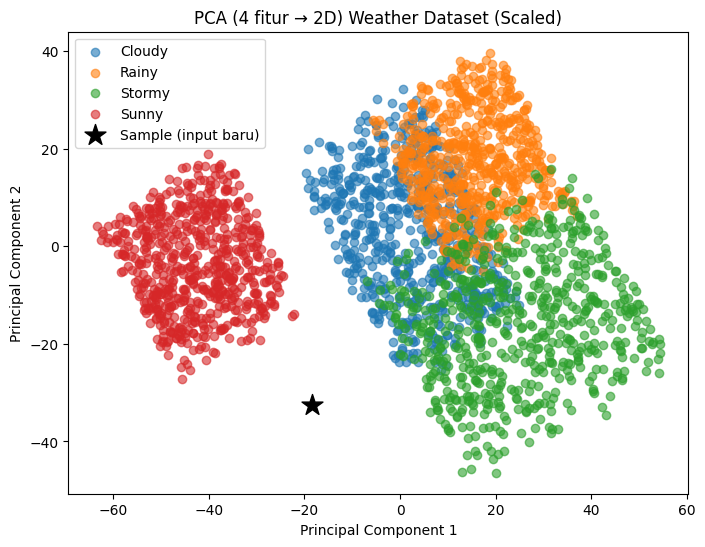


9 data cuaca paling dekat dengan input:
1. Jarak = 461.396 | Label = Stormy
   Fitur: [ 13.73  50.48  39.5  981.55]
2. Jarak = 521.511 | Label = Stormy
   Fitur: [ 14.35  51.17  34.36 976.9 ]
3. Jarak = 548.410 | Label = Stormy
   Fitur: [ 13.97  52.59  41.28 979.68]
4. Jarak = 583.746 | Label = Stormy
   Fitur: [ 13.04  52.32  40.8  986.04]
5. Jarak = 616.912 | Label = Stormy
   Fitur: [ 14.06  50.52  48.53 970.63]
6. Jarak = 641.437 | Label = Stormy
   Fitur: [  8.61  51.59  46.12 977.15]
7. Jarak = 646.676 | Label = Stormy
   Fitur: [ 11.47  53.93  41.01 979.5 ]
8. Jarak = 672.181 | Label = Stormy
   Fitur: [ 14.96  51.74  34.71 992.09]
9. Jarak = 713.796 | Label = Sunny
   Fitur: [ 25.42  25.77  14.47 983.84]


In [18]:
print("apakah kamu mau input nilai untuk di prediksi?")
pilihan = input("pilih iya atau yes jika mau input nilai, masukan lainnya jika tidak")

if pilihan.lower() in ["yes", "iya"]:

    # ======== Input dari pengguna ========
    temp = float(input("Masukkan suhu (°C): "))
    hum = float(input("Masukkan kelembapan (%): "))
    wind = float(input("Masukkan kecepatan angin (km/h): "))
    press = float(input("Masukkan tekanan udara (kPa): "))

    # ======== Bentuk jadi array numpy ========
    sample = np.array([temp, hum, wind, press])

    # ======== Prediksi menggunakan model KNN ========
    pred_label = knn.predict_one(sample)

    # ======== Tampilkan hasil prediksi ========
    print("\nPrediksi cuaca untuk input", sample, "adalah:", inv_classes[pred_label])
    visualisasi_input(sample)
    knn.show_nearest(sample, n_neighbors=9)
else:
    print("program selesai")
    exit